# 태영생막창 수익성 개선 프로젝트

> 실제 음식점 판매 데이터를 기반으로 수행된 분석 프로젝트입니다.  
> 개인정보 보호 이슈로 원본 데이터는 포함하지 않으며, 실제 데이터의 분포와 수치를 참고하여 생성한 **더미 데이터**로 분석 로직을 재현합니다.

### 분석 목표
- 매출 구조 파악 (파레토 분석)
- 수요 예측 기반 재고 전략 검토
- 공헌이익 기반 ABC 분류
- 손익분기점 분석 및 개선 전략 도출
- 이벤트 수익성 분석 (2+1 vs 할인 세트)


## 0. 라이브러리 및 환경 설정

In [1]:
import koreanize_matplotlib          # 한글 폰트 자동 설정 (NanumGothic)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)
print("환경 설정 완료")


환경 설정 완료


## 1. 더미 데이터 생성

실제 데이터의 메뉴 구성, 판매 비중, 가격·원가 구조를 참고하여 생성한 샘플 데이터입니다.


In [2]:
menu_info = {
    "돼지생막창": {"price": 14000, "cost": 3240},
    "꼬들살":     {"price": 12000, "cost": 2640},
    "소주":       {"price":  5000, "cost":  900},
    "소생막창":   {"price": 16000, "cost": 4200},
    "맥주":       {"price":  5000, "cost": 1100},
    "제주산삼겹": {"price": 14000, "cost": 3500},
    "생항정살":   {"price": 13000, "cost": 3900},
    "차돌박이":   {"price": 13000, "cost": 3900},
    "물냉면":     {"price":  8000, "cost": 2400},
    "공기밥":     {"price":  1000, "cost":  200},
    "음료수":     {"price":  2000, "cost":  600},
}

weekly_base = {
    "돼지생막창": 92,  "꼬들살":   45,  "소주":     120,
    "소생막창":   28,  "맥주":     60,  "제주산삼겹": 22,
    "생항정살":   15,  "차돌박이": 12,  "물냉면":    8,
    "공기밥":     30,  "음료수":   10,
}

records = []
for week in range(1, 49):
    peak_mult = 1.3 if 12 <= week <= 22 else 1.0
    for menu, base_qty in weekly_base.items():
        qty   = max(0, int(np.random.normal(base_qty * peak_mult, base_qty * 0.18)))
        price = menu_info[menu]["price"]
        cost  = menu_info[menu]["cost"]
        records.append({"week": week, "menu": menu, "quantity": qty,
                         "price": price, "cost": cost, "sales": qty * price})

df = pd.DataFrame(records)
print(f"생성된 레코드 수: {len(df):,}행  |  주차: 1~48  |  메뉴 수: {df['menu'].nunique()}개")
display(df.head(10))


생성된 레코드 수: 528행  |  주차: 1~48  |  메뉴 수: 11개


,week,menu,quantity,price,cost,sales
0,1,돼지생막창,100,14000,3240,1400000
1,1,꼬들살,43,12000,2640,516000
2,1,소주,133,5000,900,665000
3,1,소생막창,35,16000,4200,560000
4,1,맥주,57,5000,1100,285000
5,1,제주산삼겹,21,14000,3500,294000
6,1,생항정살,19,13000,3900,247000
7,1,차돌박이,13,13000,3900,169000
8,1,물냉면,7,8000,2400,56000
9,1,공기밥,32,1000,200,32000


## 2. 파레토 분석 (메뉴별 매출)

전체 메뉴 중 일부 품목이 매출의 대부분을 차지하는 **매출 집중 현상**을 확인합니다.


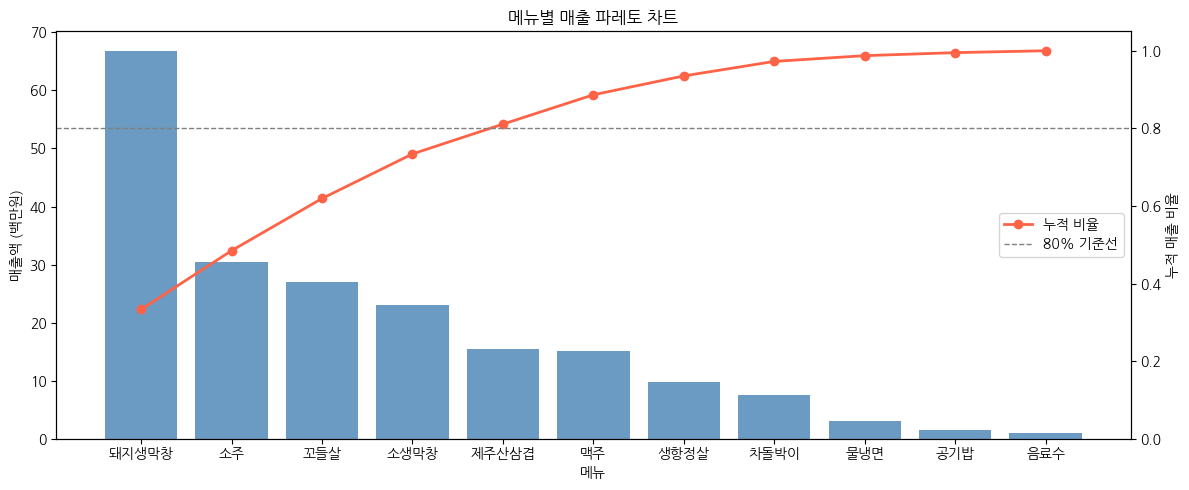


[상위 5개 메뉴 누적 비율]


,메뉴,매출액,누적비율
0,돼지생막창,66836000,0.333310
1,소주,30370000,0.484765
2,꼬들살,26952000,0.619174
3,소생막창,23024000,0.733994
4,제주산삼겹,15400000,0.810794


In [3]:
menu_sales = df.groupby("menu")["sales"].sum().sort_values(ascending=False)
pareto_df  = menu_sales.reset_index()
pareto_df["cum_ratio"] = pareto_df["sales"].cumsum() / pareto_df["sales"].sum()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(pareto_df["menu"], pareto_df["sales"] / 1e6, color="steelblue", alpha=0.8)
ax1.set_ylabel("매출액 (백만원)")
ax1.set_xlabel("메뉴")

ax2 = ax1.twinx()
ax2.plot(pareto_df["menu"], pareto_df["cum_ratio"],
         color="tomato", marker="o", linewidth=2, label="누적 비율")
ax2.axhline(0.8, color="gray", linestyle="--", linewidth=1, label="80% 기준선")
ax2.set_ylabel("누적 매출 비율")
ax2.set_ylim(0, 1.05)

plt.title("메뉴별 매출 파레토 차트")
plt.xticks(rotation=30, ha="right")
ax2.legend(loc="center right")
plt.tight_layout()
plt.show()

print("\n[상위 5개 메뉴 누적 비율]")
display(pareto_df[["menu","sales","cum_ratio"]].head(5)
        .rename(columns={"menu":"메뉴","sales":"매출액","cum_ratio":"누적비율"}))


## 3. 주차별 수요 변동 확인

실제 매장은 주 단위로 발주가 이루어지므로, **주차별 수요 패턴**을 분석합니다.


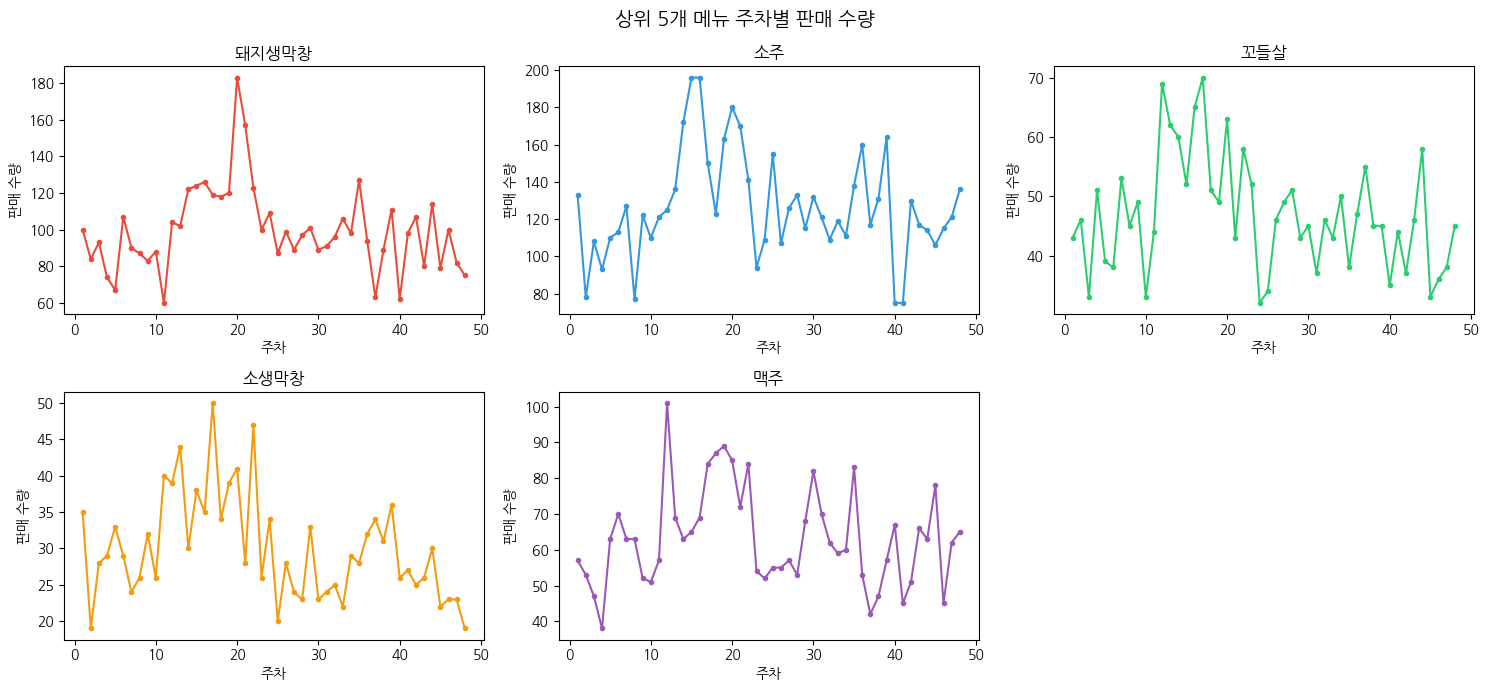

In [4]:
top5   = ["돼지생막창","소주","꼬들살","소생막창","맥주"]
colors = ["#e74c3c","#3498db","#2ecc71","#f39c12","#9b59b6"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, (menu, color) in enumerate(zip(top5, colors)):
    data = df[df["menu"] == menu].sort_values("week")
    axes[i].plot(data["week"], data["quantity"],
                 color=color, linewidth=1.5, marker="o", markersize=3)
    axes[i].set_title(menu)
    axes[i].set_xlabel("주차")
    axes[i].set_ylabel("판매 수량")

axes[5].axis("off")
plt.suptitle("상위 5개 메뉴 주차별 판매 수량", fontsize=14)
plt.tight_layout()
plt.show()


## 4. 수요 예측 함수 정의

이동평균법, 단순지수평활법(SES), 이중지수평활법(DES) 세 가지 기법을 직접 구현합니다.


In [5]:
def moving_average(series, window=4):
    """단순 이동평균법"""
    return series.rolling(window=window).mean()

def simple_exponential_smoothing(series, alpha=0.5):
    """단순지수평활법 (SES) – 수준만 반영"""
    result = [series.iloc[0]]
    for val in series.iloc[1:]:
        result.append(alpha * val + (1 - alpha) * result[-1])
    return pd.Series(result, index=series.index)

def double_exponential_smoothing(series, alpha=0.5, beta=0.3):
    """이중지수평활법 (Holt) – 수준 + 추세 반영"""
    level = series.iloc[0]
    trend = series.iloc[1] - series.iloc[0]
    result = [level + trend]
    for val in series.iloc[1:]:
        prev_level = level
        level = alpha * val + (1 - alpha) * (level + trend)
        trend = beta * (level - prev_level) + (1 - beta) * trend
        result.append(level + trend)
    return pd.Series(result, index=series.index)

def mape(actual, pred):
    """MAPE – 실제값 0인 구간 제외"""
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

print("예측 함수 정의 완료 (MA / SES / DES / MAPE)")


예측 함수 정의 완료 (MA / SES / DES / MAPE)


## 5. 수요구간별 예측법 비교

메뉴별로 **성수기 / 비수기** 구간을 분리하고,  
세 가지 예측법의 MAPE를 비교하여 최적 기법을 선정합니다.


In [6]:
target_menus = {
    "돼지생막창": (12, 22),
    "소생막창":   (10, 25),
    "꼬들살":     (12, 22),
    "소주":       (14, 20),
}

all_results = []

for menu, peak_range in target_menus.items():
    data = df[df["menu"] == menu].sort_values("week").copy()

    for period_name, subset in [
        ("성수기", data[data["week"].between(*peak_range)]),
        ("비수기", data[~data["week"].between(*peak_range)]),
    ]:
        qty = subset["quantity"].reset_index(drop=True)
        if len(qty) < 6:
            continue

        preds = {
            "4주 이동평균":              moving_average(qty, 4),
            "단순지수평활(a=0.5)":       simple_exponential_smoothing(qty, 0.5),
            "이중지수평활(a=0.5,b=0.3)": double_exponential_smoothing(qty, 0.5, 0.3),
        }
        for method, pred in preds.items():
            idx = pred.dropna().index
            all_results.append({
                "메뉴": menu, "구간": period_name,
                "예측법": method, "MAPE(%)": round(mape(qty[idx], pred[idx]), 1)
            })

result_df = pd.DataFrame(all_results)

for menu in target_menus:
    sub   = result_df[result_df["메뉴"] == menu]
    pivot = sub.pivot(index="예측법", columns="구간", values="MAPE(%)")
    print(f"\n{'='*52}")
    print(f"  {menu} – 예측법별 MAPE 비교")
    print(f"{'='*52}")
    display(pivot)



  돼지생막창 – 예측법별 MAPE 비교


구간,비수기,성수기
예측법,,
4주 이동평균,12.2,9.3
단순지수평활(a=0.5),8.4,4.6
"이중지수평활(a=0.5,b=0.3)",10.2,6.0



  소생막창 – 예측법별 MAPE 비교


구간,비수기,성수기
예측법,,
4주 이동평균,10.5,17.6
단순지수평활(a=0.5),7.4,11.6
"이중지수평활(a=0.5,b=0.3)",17.3,24.4



  꼬들살 – 예측법별 MAPE 비교


구간,비수기,성수기
예측법,,
4주 이동평균,12.9,13.6
단순지수평활(a=0.5),8.3,8.0
"이중지수평활(a=0.5,b=0.3)",8.6,10.9



  소주 – 예측법별 MAPE 비교


구간,비수기,성수기
예측법,,
4주 이동평균,12.9,17.9
단순지수평활(a=0.5),8.7,7.7
"이중지수평활(a=0.5,b=0.3)",15.7,15.8


### 5-1. 최적 예측법 시각화 (돼지생막창)

MAPE가 가장 낮은 **4주 이동평균법**으로 성수기·비수기 예측 결과를 시각화합니다.


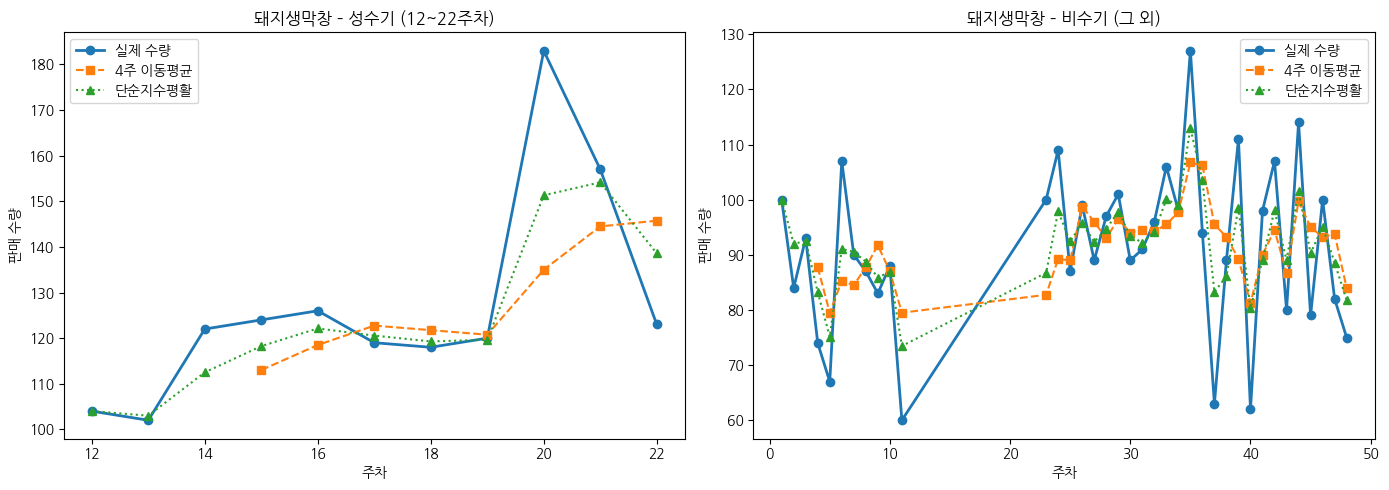

In [7]:
sample    = df[df["menu"] == "돼지생막창"].sort_values("week").copy().reset_index(drop=True)
peak_mask = sample["week"].between(12, 22)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mask, title in zip(
    axes,
    [peak_mask, ~peak_mask],
    ["성수기 (12~22주차)", "비수기 (그 외)"]
):
    sub      = sample[mask].reset_index(drop=True)
    qty      = sub["quantity"]
    pred_ma  = moving_average(qty, 4)
    pred_ses = simple_exponential_smoothing(qty, 0.5)

    ax.plot(sub["week"], qty,      label="실제 수량",    marker="o",  linewidth=2)
    ax.plot(sub["week"], pred_ma,  label="4주 이동평균", marker="s",  linestyle="--")
    ax.plot(sub["week"], pred_ses, label="단순지수평활", marker="^",  linestyle=":")
    ax.set_title(f"돼지생막창 – {title}")
    ax.set_xlabel("주차")
    ax.set_ylabel("판매 수량")
    ax.legend()

plt.tight_layout()
plt.show()


## 6. 공헌이익 기반 ABC 분류

매출액이 아닌 **공헌이익(판매가 – 변동원가)** 총액 기준으로 품목을 A/B/C 등급으로 분류합니다.

| 등급 | 기준 | 전략 |
|------|------|------|
| A | 누적 80% 이내 | ROP·안전재고 설정, 집중 관리 |
| B | 누적 95% 이내 | 정기 발주 |
| C | 그 외 | 필요시 발주 |


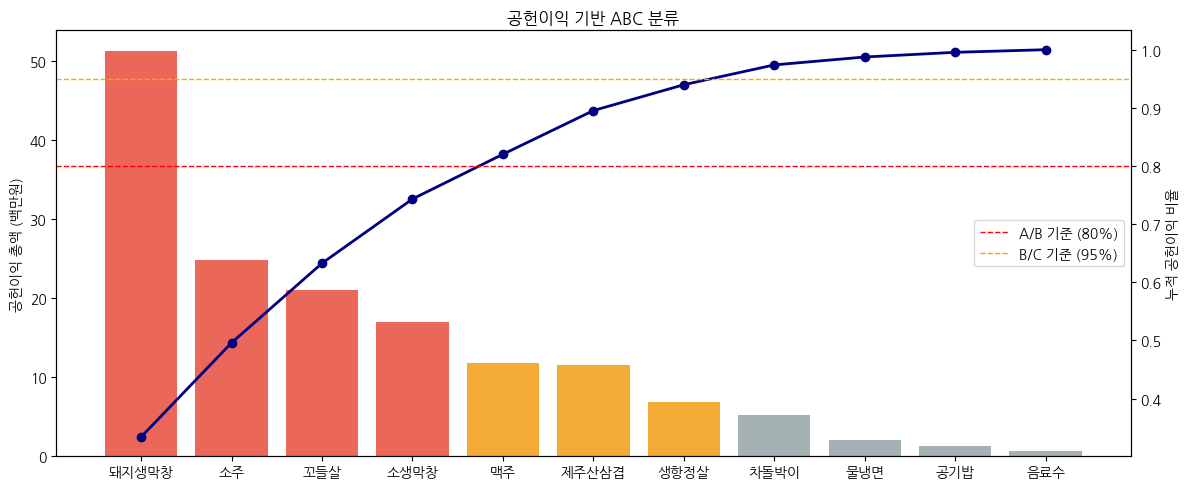

,메뉴,공헌이익 총액,누적비율,등급
0,돼지생막창,51368240,0.334101,A
1,소주,24903400,0.496074,A
2,꼬들살,21022560,0.632805,A
3,소생막창,16980200,0.743245,A
4,맥주,11828700,0.820180,B
5,제주산삼겹,11550000,0.895301,B
6,생항정살,6834100,0.939750,B
7,차돌박이,5241600,0.973842,C
8,물냉면,2088800,0.987428,C
9,공기밥,1240000,0.995493,C


In [8]:
df["contribution"]       = df["price"] - df["cost"]
df["total_contribution"] = df["contribution"] * df["quantity"]

contrib = df.groupby("menu")["total_contribution"].sum().sort_values(ascending=False)
abc_df  = contrib.reset_index()
abc_df["cum_ratio"] = abc_df["total_contribution"].cumsum() / abc_df["total_contribution"].sum()
abc_df["등급"] = abc_df["cum_ratio"].apply(
    lambda x: "A" if x <= 0.80 else ("B" if x <= 0.95 else "C")
)

colors_map = {"A": "#e74c3c", "B": "#f39c12", "C": "#95a5a6"}
bar_colors = [colors_map[g] for g in abc_df["등급"]]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(abc_df["menu"], abc_df["total_contribution"] / 1e6, color=bar_colors, alpha=0.85)
ax1.set_ylabel("공헌이익 총액 (백만원)")

ax2 = ax1.twinx()
ax2.plot(abc_df["menu"], abc_df["cum_ratio"], color="navy", marker="o", linewidth=2)
ax2.axhline(0.80, color="red",    linestyle="--", linewidth=1, label="A/B 기준 (80%)")
ax2.axhline(0.95, color="orange", linestyle="--", linewidth=1, label="B/C 기준 (95%)")
ax2.set_ylabel("누적 공헌이익 비율")
ax2.legend(loc="center right")

plt.title("공헌이익 기반 ABC 분류")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(abc_df[["menu","total_contribution","cum_ratio","등급"]]
        .rename(columns={"menu":"메뉴","total_contribution":"공헌이익 총액","cum_ratio":"누적비율"}))


## 7. A등급 품목 – 안전재고 및 ROP 산정

- **안전재고** = Z × σ × LT  
- **ROP** = 평균수요 × LT + 안전재고  
- Z = 1.65 (서비스 수준 95%)


,품목,평균수요(주),표준편차,리드타임(주),안전재고,ROP
0,돼지생막창,91.8,20.83,0.29,10.0,36.6
1,꼬들살,45.4,11.74,0.14,2.7,9.1
2,소주,120.2,20.00,0.29,9.6,44.5


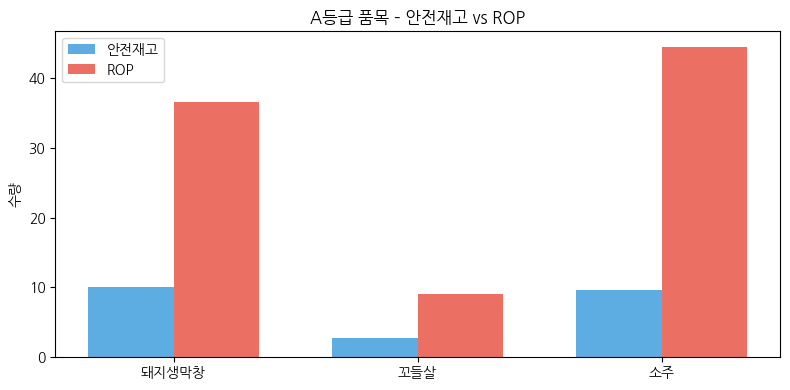

In [9]:
a_items = [
    {"품목": "돼지생막창", "평균수요(주)": 91.8,  "표준편차": 20.83, "리드타임(주)": 0.29},
    {"품목": "꼬들살",     "평균수요(주)": 45.4,  "표준편차": 11.74, "리드타임(주)": 0.14},
    {"품목": "소주",       "평균수요(주)": 120.2, "표준편차": 20.0,  "리드타임(주)": 0.29},
]
z = 1.65

rows = []
for item in a_items:
    ss  = round(z * item["표준편차"] * item["리드타임(주)"], 1)
    rop = round(item["평균수요(주)"] * item["리드타임(주)"] + ss, 1)
    rows.append({**item, "안전재고": ss, "ROP": rop})

rop_df = pd.DataFrame(rows)
display(rop_df)

fig, ax = plt.subplots(figsize=(8, 4))
x     = range(len(rop_df))
width = 0.35
ax.bar([i - width/2 for i in x], rop_df["안전재고"], width, label="안전재고", color="#3498db", alpha=0.8)
ax.bar([i + width/2 for i in x], rop_df["ROP"],     width, label="ROP",     color="#e74c3c", alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(rop_df["품목"])
ax.set_ylabel("수량")
ax.set_title("A등급 품목 – 안전재고 vs ROP")
ax.legend()
plt.tight_layout()
plt.show()


## 8. 손익분기점(BEP) 분석

고정비와 공헌이익률을 기반으로 손익분기점 매출액을 산출하고 실제 매출과 비교합니다.


고정비 합계           :     8,936,000 원
가중 공헌이익률       :          0.69
조정 공헌이익률       :          0.61  (카드수수료 · 부식자재 반영)
──────────────────────────────────────────────
BEP (기본)            :    12,950,725 원
BEP (조정) ★실질 BEP :    14,649,180 원
실제 매출             :    15,646,000 원
BEP 초과분            :       996,820 원


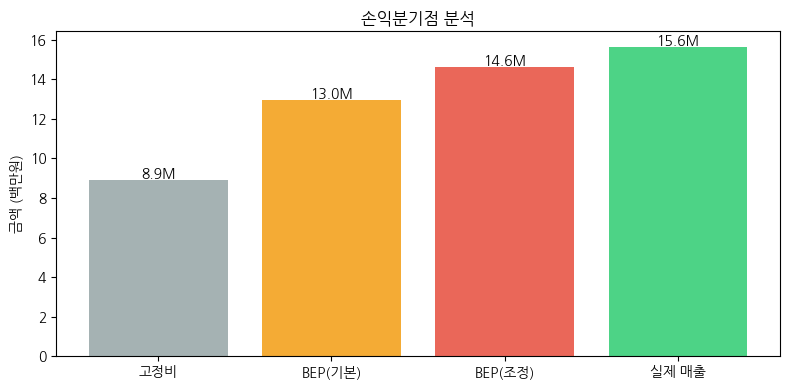

In [10]:
fixed_cost   = 8_936_000
base_cr      = 0.69   # 주재료 원가 기준 가중 공헌이익률
adjusted_cr  = 0.61   # 카드수수료·부식자재 반영 후 조정
actual_sales = 15_646_000

bep_base     = fixed_cost / base_cr
bep_adjusted = fixed_cost / adjusted_cr

print(f"고정비 합계           : {fixed_cost:>13,.0f} 원")
print(f"가중 공헌이익률       :          {base_cr:.2f}")
print(f"조정 공헌이익률       :          {adjusted_cr:.2f}  (카드수수료 · 부식자재 반영)")
print(f"{'─'*46}")
print(f"BEP (기본)            : {bep_base:>13,.0f} 원")
print(f"BEP (조정) ★실질 BEP : {bep_adjusted:>13,.0f} 원")
print(f"실제 매출             : {actual_sales:>13,.0f} 원")
print(f"BEP 초과분            : {actual_sales - bep_adjusted:>13,.0f} 원")

labels = ["고정비", "BEP(기본)", "BEP(조정)", "실제 매출"]
values = [fixed_cost, bep_base, bep_adjusted, actual_sales]
colors = ["#95a5a6", "#f39c12", "#e74c3c", "#2ecc71"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, [v/1e6 for v in values], color=colors, alpha=0.85)
ax.set_ylabel("금액 (백만원)")
ax.set_title("손익분기점 분석")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val/1e6:.1f}M", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## 9. 이벤트 수익성 분석

### 9-1. 2+1 이벤트 – 단일 메뉴 수익성

동일 메뉴 2인분 주문 시 1인분 추가 제공하는 이벤트의 단일 품목 수익성을 분석합니다.


In [11]:
event_df = pd.DataFrame({
    "구분":       ["비이벤트 (2025.02)", "이벤트 (2024.02)"],
    "판매수량":   [355, 366],
    "총제공수량": [355, 549],
    "총매출":     [4_970_000, 5_124_000],
    "총원가":     [1_150_200, 1_778_760],
})
event_df["총이익"] = event_df["총매출"] - event_df["총원가"]
event_df["이익률"] = (event_df["총이익"] / event_df["총매출"]).map("{:.1%}".format)
display(event_df)

profit_diff = event_df.loc[1,"총이익"] - event_df.loc[0,"총이익"]
print(f"\n총이익 변화: {profit_diff:+,.0f}원  →  단일 품목 기준 {'손실 발생' if profit_diff < 0 else '이익'}")


,구분,판매수량,총제공수량,총매출,총원가,총이익,이익률
0,비이벤트 (2025.02),355,355,4970000,1150200,3819800,76.9%
1,이벤트 (2024.02),366,549,5124000,1778760,3345240,65.3%



총이익 변화: -474,560원  →  단일 품목 기준 손실 발생


### 9-2. 전체 매출 변화 – 교차 판매 효과

In [12]:
total_df = pd.DataFrame({
    "구분":     ["비이벤트 (2025.02)", "이벤트 (2024.02)"],
    "판매건수": [1_705, 1_866],
    "전체매출": [14_899_000, 16_563_500],
})
display(total_df)

print(f"\n전체 매출 증가: +{total_df.loc[1,'전체매출'] - total_df.loc[0,'전체매출']:,.0f}원")
print(f"판매 건수 증가: +{total_df.loc[1,'판매건수']  - total_df.loc[0,'판매건수']}건")
print("→ 단일 품목 손실에도 불구하고, 고객 유입·교차 판매로 전체 매출은 증가")


,구분,판매건수,전체매출
0,비이벤트 (2025.02),1705,14899000
1,이벤트 (2024.02),1866,16563500



전체 매출 증가: +1,664,500원
판매 건수 증가: +161건
→ 단일 품목 손실에도 불구하고, 고객 유입·교차 판매로 전체 매출은 증가


### 9-3. 개선안 – 10% 할인 세트 수익성 비교

,구성,판매가,원가,공헌이익,공헌이익률
0,정가 판매,43000,11160,31840,74.0%
1,10% 할인 세트 (돼지생막창2 + 차돌박이1),38700,11160,27540,71.2%


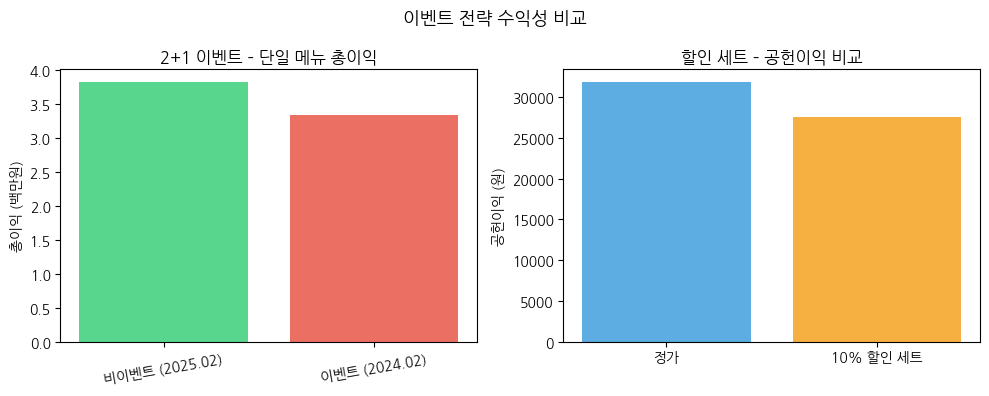


→ 10% 할인 세트는 2+1 대비 원가 부담 없이 공헌이익률 유지 가능
→ 차돌박이(냉동 보관·손질 불필요) 특성상 운영 효율도 우수


In [13]:
set_df = pd.DataFrame({
    "구성":   ["정가 판매", "10% 할인 세트 (돼지생막창2 + 차돌박이1)"],
    "판매가": [43_000, 38_700],
    "원가":   [11_160, 11_160],
})
set_df["공헌이익"]  = set_df["판매가"] - set_df["원가"]
set_df["공헌이익률"] = (set_df["공헌이익"] / set_df["판매가"]).map("{:.1%}".format)
display(set_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(event_df["구분"], event_df["총이익"] / 1e6,
            color=["#2ecc71","#e74c3c"], alpha=0.8)
axes[0].set_title("2+1 이벤트 – 단일 메뉴 총이익")
axes[0].set_ylabel("총이익 (백만원)")
axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(["정가", "10% 할인 세트"],
            [set_df.loc[0,"공헌이익"], set_df.loc[1,"공헌이익"]],
            color=["#3498db","#f39c12"], alpha=0.8)
axes[1].set_title("할인 세트 – 공헌이익 비교")
axes[1].set_ylabel("공헌이익 (원)")

plt.suptitle("이벤트 전략 수익성 비교", fontsize=13)
plt.tight_layout()
plt.show()

print("\n→ 10% 할인 세트는 2+1 대비 원가 부담 없이 공헌이익률 유지 가능")
print("→ 차돌박이(냉동 보관·손질 불필요) 특성상 운영 효율도 우수")


## 10. 결론

| 분석 항목 | 주요 결과 |
|-----------|-----------|
| 파레토 분석 | 상위 5개 메뉴가 전체 매출의 약 80% 차지 |
| 수요 예측 | 안정 구간에서 이동평균·SES 유효, 급변 구간에서 오차 증가 |
| ABC 분류 | 돼지생막창·꼬들살·소주가 A등급 → ROP / 안전재고 설정 |
| 손익분기점 | 조정 BEP 약 1,464만원, 현재 매출 약 100만원 초과 달성 |
| 이벤트 | 2+1은 단일 품목 손실 / 전체 매출 증가, 10% 할인 세트가 더 안정적 |

> **핵심 시사점**: 외식업처럼 수요 변동이 큰 업종에서는 예측 기반 전략의 한계를 인식하고,  
> ABC 분류·손익 분석을 병행하는 **실용적 전략**이 더 효과적임을 확인.
